In [1]:
from app.config import load_config, load_classes
from app.main import get_video_sources
from app.pipeline import run_pipeline
from app.monitoring import load_events, build_summary, print_summary
from app.dashboard import create_dashboard

In [2]:
CONFIG = load_config()
OBJECT_CLASSES = load_classes()

In [3]:
VIDEO_SOURCES = get_video_sources(CONFIG)

print("Sources:")
for i, source in enumerate(VIDEO_SOURCES, start=1):
    print(f"  Camera {i}: {source}")

[INFO] Found 4 video source(s).
Sources:
  Camera 1: videos\10531835-uhd_2160_3840_30fps.mp4
  Camera 2: videos\13395455_2160_3840_60fps.mp4
  Camera 3: videos\sample-5s-720p.mp4
  Camera 4: videos\sample_video.mp4


In [4]:
run_pipeline(VIDEO_SOURCES, CONFIG, OBJECT_CLASSES)

[Camera 3] Producer done | Pushed: 35 | Dropped: 0 | Drop rate: 0.00%
[Camera 4] Producer done | Pushed: 50 | Dropped: 31 | Drop rate: 0.00%
[Worker 1] Cam3 Frame0: [('bench', 0.75), ('truck', 0.64), ('car', 0.5)]
[Worker 1] Cam3 Frame5: [('bench', 0.65), ('car', 0.55), ('truck', 0.44), ('car', 0.37)]
[Worker 1] Cam3 Frame10: [('truck', 0.83), ('bench', 0.7), ('car', 0.5)]
[Worker 1] Cam3 Frame15: [('truck', 0.68), ('bench', 0.61), ('bench', 0.5), ('car', 0.38), ('person', 0.36)]
[Worker 1] Cam3 Frame20: [('truck', 0.83), ('bench', 0.65), ('car', 0.45)]
[Worker 1] Cam3 Frame25: [('bench', 0.71), ('truck', 0.65), ('car', 0.5), ('person', 0.36), ('bench', 0.33), ('car', 0.31)]
[Worker 1] Cam3 Frame30: [('bench', 0.75), ('car', 0.5), ('truck', 0.34)]
[Worker 1] Cam4 Frame0: No detection
[Worker 1] Cam3 Frame35: [('bench', 0.65), ('car', 0.62), ('car', 0.43)]
[Worker 1] Cam4 Frame5: No detection
[Worker 1] Cam3 Frame40: [('car', 0.6), ('car', 0.57), ('bench', 0.53)]
[Worker 1] Cam4 Frame10

In [5]:
LOG_FILE = CONFIG["output"]["log_file"]
events = load_events(LOG_FILE)
camera_data = build_summary(events)
print_summary(camera_data)


PIPELINE MONITORING SUMMARY

Camera 1
  Frames pushed : 21
  Frames dropped: 35
  Drop rate     : 0.00%
  Max queue     : 100
  Max fullness  : 99.0%
  Avg lag       : 51.87 sec
  Max lag       : 66.55 sec
  Detections    : 305

Camera 2
  Frames pushed : 38
  Frames dropped: 62
  Drop rate     : 0.00%
  Max queue     : 100
  Max fullness  : 99.0%
  Avg lag       : 40.46 sec
  Max lag       : 66.33 sec
  Detections    : 67

Camera 3
  Frames pushed : 35
  Frames dropped: 0
  Drop rate     : 0.00%
  Max queue     : 99
  Max fullness  : 99.0%
  Avg lag       : 44.77 sec
  Max lag       : 62.94 sec
  Detections    : 118

Camera 4
  Frames pushed : 50
  Frames dropped: 31
  Drop rate     : 0.00%
  Max queue     : 100
  Max fullness  : 99.0%
  Avg lag       : 57.13 sec
  Max lag       : 66.83 sec
  Detections    : 15


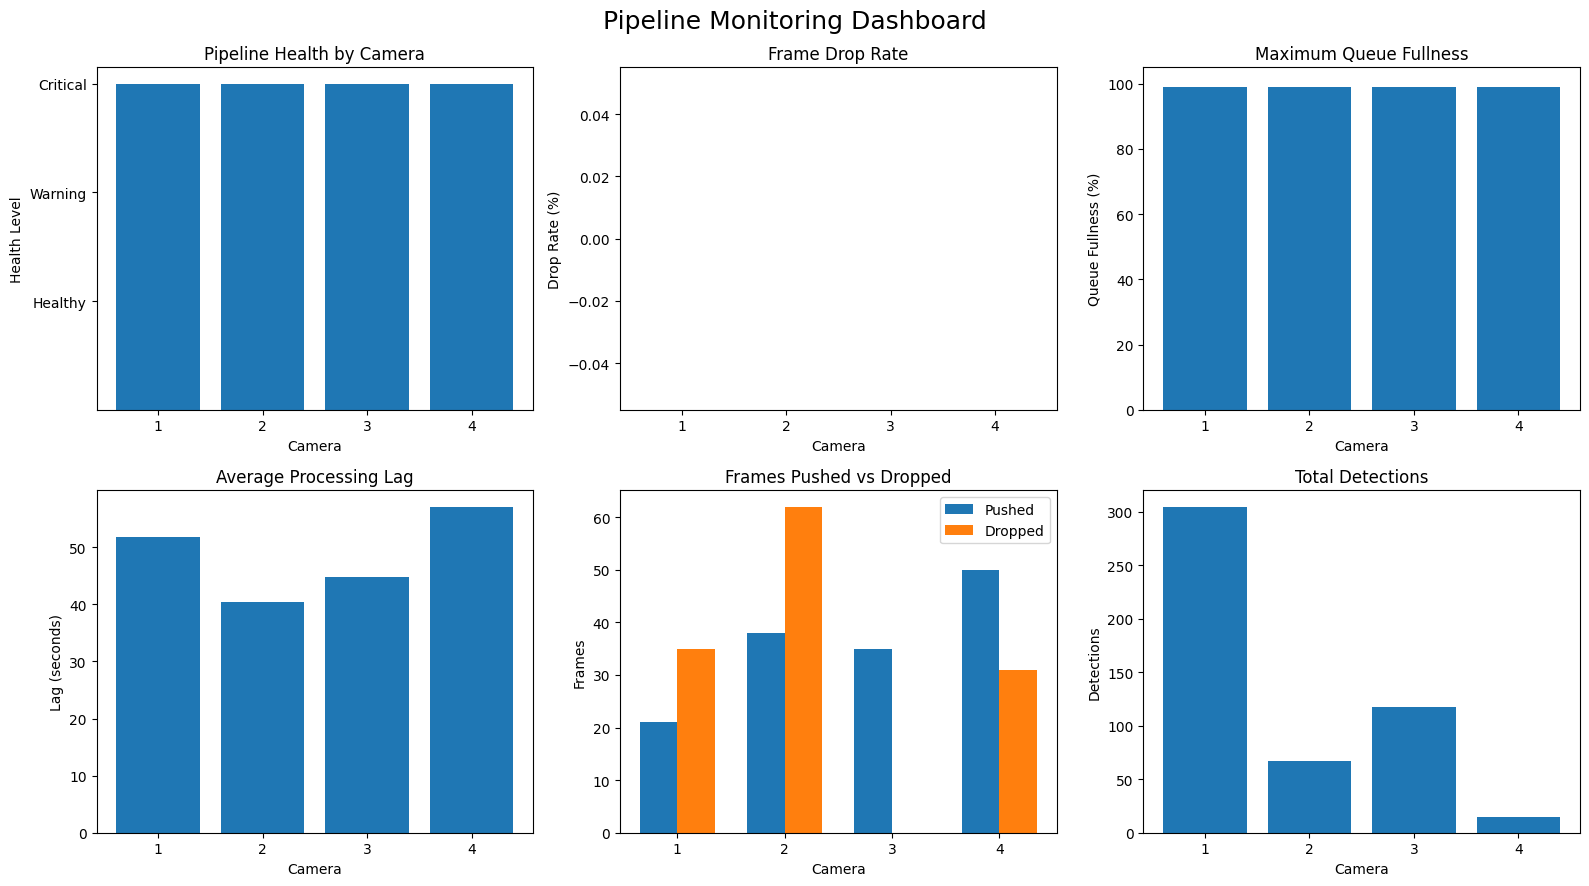

Dashboard saved to: results/pipeline_monitoring_dashboard.png


In [6]:
DASHBOARD_PATH = CONFIG["output"]["dashboard_file"]
create_dashboard(camera_data, DASHBOARD_PATH)